In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
#get music mood data
data = pd.read_csv("spotifyMoodDataForTraining/data_moods.csv")
data.dataframeName = "data_moods.csv"
data.shape

(686, 19)

In [3]:
data["mood"].value_counts()

mood
Sad          197
Calm         195
Energetic    154
Happy        140
Name: count, dtype: int64

In [4]:
data.head()

,name,album,artist,id,release_date,popularity,duration_ms,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [5]:
#get more energetic and happy data
energetic_happy_data = pd.read_csv("spotifyMoodDataForTraining/tracks-happy-energetic.csv")
energetic_happy_data.dataframeName = "tracks-happy-energetic.csv"
energetic_happy_data.shape

(199, 13)

In [6]:
energetic_happy_data["mood"].value_counts()

mood
Energetic    100
Happy         99
Name: count, dtype: int64

In [7]:
energetic_happy_data.head()

,Unnamed: 0,energy,liveness,tempo,speechiness,acousticness,instrumentalness,danceability,duration_ms,loudness,valence,id,mood
0,0,0.549,0.220,130.749,0.0698,0.000798,0.004850,0.357,244573,-7.843,0.531,3kdMzXOcrDIdSWLdONHNK5,Energetic
1,1,0.975,0.160,129.022,0.0618,0.000051,0.713000,0.594,205760,-3.210,0.899,3rFEKOClXOdNFO6fQGuQ9j,Energetic
2,2,0.724,0.237,130.037,0.0313,0.000827,0.000144,0.512,198081,-5.912,0.531,4G3DWijMhNkWZwLcxnDI0H,Energetic
3,3,0.828,0.060,126.037,0.0536,0.001750,0.013600,0.542,194626,-3.910,0.785,4YZVtRbdGOhHdGNi4JpCL5,Energetic
4,4,0.886,0.256,161.939,0.0714,0.000029,0.000005,0.252,210560,-4.678,0.498,7GvkOFkNsM6Exnkyqeajqm,Energetic


In [8]:
data_track_features = data.drop(["name", "album", "artist", "id", "release_date", "popularity", "key", "time_signature"], axis=1)
data_track_features.shape

(686, 11)

In [9]:
energetic_happy_data = energetic_happy_data.drop(["Unnamed: 0", "id"], axis=1)
energetic_happy_data.shape

(199, 11)

In [10]:
data_track_features.head()

,duration_ms,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,mood
0,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,Happy
1,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,Sad
2,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,Sad
3,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,Happy
4,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,Energetic


In [11]:
energetic_happy_data.head()

,energy,liveness,tempo,speechiness,acousticness,instrumentalness,danceability,duration_ms,loudness,valence,mood
0,0.549,0.220,130.749,0.0698,0.000798,0.004850,0.357,244573,-7.843,0.531,Energetic
1,0.975,0.160,129.022,0.0618,0.000051,0.713000,0.594,205760,-3.210,0.899,Energetic
2,0.724,0.237,130.037,0.0313,0.000827,0.000144,0.512,198081,-5.912,0.531,Energetic
3,0.828,0.060,126.037,0.0536,0.001750,0.013600,0.542,194626,-3.910,0.785,Energetic
4,0.886,0.256,161.939,0.0714,0.000029,0.000005,0.252,210560,-4.678,0.498,Energetic


In [12]:
enhanced_data = pd.concat([data_track_features, energetic_happy_data], ignore_index=True)
enhanced_data.shape

(885, 11)

In [13]:
enhanced_data.head()

,duration_ms,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,mood
0,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,Happy
1,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,Sad
2,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,Sad
3,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,Happy
4,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,Energetic


In [14]:
enhanced_data["mood"].value_counts()

mood
Energetic    254
Happy        239
Sad          197
Calm         195
Name: count, dtype: int64

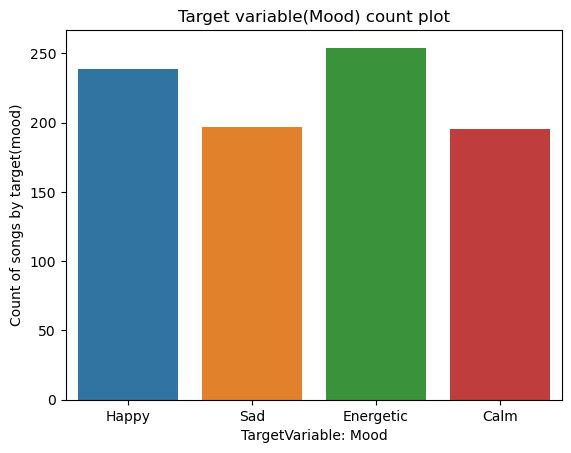

In [15]:
#plotting the target variable
import seaborn as sns

sns.countplot(enhanced_data, x="mood")
plt.xlabel("TargetVariable: Mood")
plt.ylabel("Count of songs by target(mood)")
plt.title("Target variable(Mood) count plot")
plt.show()

In [16]:
#check for null values in my data
enhanced_data.isnull().sum()

duration_ms         0
danceability        0
acousticness        0
energy              0
instrumentalness    0
liveness            0
valence             0
loudness            0
speechiness         0
tempo               0
mood                0
dtype: int64

In [17]:
#separate target and features columns
target = enhanced_data.iloc[:, -1]
features = enhanced_data.iloc[:, :-1]

print(target.name)
print(features.columns)

mood
Index(['duration_ms', 'danceability', 'acousticness', 'energy',
       'instrumentalness', 'liveness', 'valence', 'loudness', 'speechiness',
       'tempo'],
      dtype='object')


In [18]:
#perform label encoding for target column 
from sklearn.preprocessing import LabelEncoder

 # Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit label encoder and transform the 'mood' column
unique_moods = target.unique()
unique_mood_encoded = label_encoder.fit_transform(unique_moods)

print("Original Labels:", unique_moods)
print("Encoded Labels:", unique_mood_encoded )

Original Labels: ['Happy' 'Sad' 'Energetic' 'Calm']
Encoded Labels: [2 3 1 0]


In [19]:
target_unique_encoded = pd.DataFrame({'mood':unique_moods,'encode':unique_mood_encoded}).sort_values(['encode'],ascending=True)
target_unique_encoded

,mood,encode
3,Calm,0
2,Energetic,1
0,Happy,2
1,Sad,3


In [20]:
#encoding the target set to integer values 
target_encoded = label_encoder.fit_transform(target)
target_encoded.shape

(885,)

In [21]:
#split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.2, random_state=42)

In [102]:
unique_train_values, train_value_counts = np.unique(y_train, return_counts=True)
train_values = pd.DataFrame({'mood':unique_moods,'encode':unique_train_values, 'count':train_value_counts})
train_values

,mood,encode,count
0,Calm,0,150
1,Energetic,1,203
2,Happy,2,198
3,Sad,3,157


In [99]:
print(unique_train_values, train_value_counts)

[0 1 2 3] [150 203 198 157]


In [98]:
unique_test_values, test_value_counts = np.unique(y_test, return_counts=True)
test_values = pd.DataFrame({'mood':unique_moods, 'encode':unique_test_values, 'count':test_value_counts})
test_values

,mood,encode,count
0,Calm,0,45
1,Energetic,1,51
2,Happy,2,41
3,Sad,3,40


In [68]:
print(unique_test_values, test_value_counts)

[0 1 2 3] [45 51 41 40]


In [24]:
#do exhaustive feature parameter search 
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.ensemble import RandomForestClassifier

efs = EFS(RandomForestClassifier(n_jobs=-1), min_features=1, max_features=10, scoring='f1_macro', cv=5, n_jobs=-1).fit(X_train, y_train)

Features: 1023/1023

In [25]:
best_features = efs.best_feature_names_
best_features

('duration_ms',
 'danceability',
 'acousticness',
 'energy',
 'instrumentalness',
 'valence',
 'speechiness',
 'tempo')

In [26]:
efs.best_score_

0.8214115449390267

In [27]:
#creating my random forest classifier model with all the features and without hyperparameter tunning 
clf = RandomForestClassifier(n_jobs=-1)

#train my model
clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1)

In [28]:
#testing my model with my test and train data
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

In [29]:
# compare accuracy and f1 score for training and test data
from sklearn.metrics import accuracy_score, f1_score

train_accuracy_score = accuracy_score(y_train,y_pred_train)
test_accuracy_score = accuracy_score(y_test,y_pred_test)
print("Train Accuracy Score", train_accuracy_score)
print("Test Accuracy Score", test_accuracy_score)

print()
train_f1_score = f1_score(y_train,y_pred_train, average='macro')
test_f1_score = f1_score(y_test,y_pred_test, average='macro')
print("Train F1 Score", train_f1_score)
print("Test F1 Score", test_f1_score)
print("How far off is the model from the testing data to the training data: ", train_f1_score - test_f1_score)

Train Accuracy Score 0.998587570621469
Test Accuracy Score 0.7909604519774012

Train F1 Score 0.9987528379933444
Test F1 Score 0.7915839121148661
How far off is the model from the testing data to the training data:  0.20716892587847824


In [30]:
#print the classification report for the clf
from sklearn.metrics import classification_report

classification_report = classification_report(y_test, y_pred_test, digits=4)
print(classification_report)

              precision    recall  f1-score   support

           0     0.8723    0.9111    0.8913        45
           1     0.8222    0.7255    0.7708        51
           2     0.6346    0.8049    0.7097        41
           3     0.8788    0.7250    0.7945        40

    accuracy                         0.7910       177
   macro avg     0.8020    0.7916    0.7916       177
weighted avg     0.8043    0.7910    0.7926       177



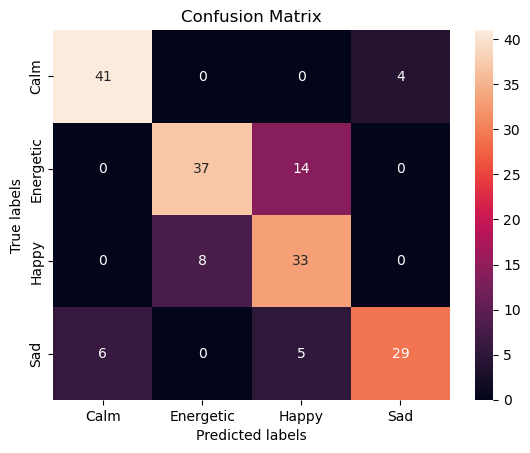

In [31]:
#get the confusion metric to see how many moods have been predicted wrong
from sklearn.metrics import confusion_matrix
#Create the confusion matrix using test data and predictions
confusion_matrix = confusion_matrix(y_test, y_pred_test)

#plot the confusion matrix
ax = plt.subplot()
sns.heatmap(confusion_matrix,annot=True,ax=ax)
labels = target_unique_encoded['mood'].tolist()
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)
plt.show()

In [32]:
#set params to perform hyperparameter tunning 
from sklearn.metrics import make_scorer

parameters = {
    'max_depth': [1,5,10,15, 20],
    'min_samples_leaf': [1,2,3,4,5],
    'min_samples_split': [2,5,10],
    'criterion':['gini', 'entropy'],
    'n_estimators': [50, 100, 200],
}
scorer = make_scorer(f1_score, average="macro")

In [33]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

def generate_clf_from_search(grid_or_random, clf, parameters, scorer, X, y):
    if grid_or_random == "Grid":
        search_obj = GridSearchCV(clf, parameters, scoring=scorer)
    elif grid_or_random == "Random":
        search_obj = RandomizedSearchCV(clf, parameters, scoring=scorer)
    fit_obj = search_obj.fit(X, y)
    best_clf = fit_obj.best_estimator_
    return best_clf

In [34]:
best_clf_grid = generate_clf_from_search("Grid", clf, parameters, scorer, X_train, y_train)
best_clf_grid

RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_leaf=2,
                       min_samples_split=10, n_jobs=-1)

In [35]:
best_clf_grid.fit(X_train, y_train)
best_grid_train_prediction = best_clf_grid.predict(X_train)
best_grid_test_prediction = best_clf_grid.predict(X_test)

grid_train_f1 = f1_score(y_train, best_grid_train_prediction, average='macro')
grid_test_f1 = f1_score(y_test, best_grid_test_prediction, average='macro')
print("Training F1 score: ", grid_train_f1)
print("Testing F1 score: ", grid_test_f1)
print("How far off is the model from the testing data to the training data: ", grid_train_f1 - grid_test_f1)

Training F1 score:  0.9596924492822714
Testing F1 score:  0.8088078984041716
How far off is the model from the testing data to the training data:  0.15088455087809982


In [36]:
from sklearn.metrics import classification_report

grid_classification_report = classification_report(y_test, best_grid_test_prediction, digits=4)
print(grid_classification_report)

              precision    recall  f1-score   support

           0     0.9111    0.9111    0.9111        45
           1     0.8298    0.7647    0.7959        51
           2     0.6471    0.8049    0.7174        41
           3     0.8824    0.7500    0.8108        40

    accuracy                         0.8079       177
   macro avg     0.8176    0.8077    0.8088       177
weighted avg     0.8200    0.8079    0.8104       177



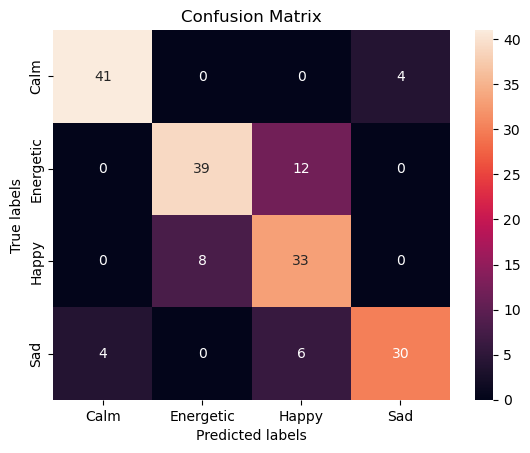

In [37]:
#get the confusion metric to see how many moods have been predicted wrong
from sklearn.metrics import confusion_matrix
#Create the confusion matrix using test data and predictions
confusion_matrix = confusion_matrix(y_test, best_grid_test_prediction)

#plot the confusion matrix
ax = plt.subplot()
sns.heatmap(confusion_matrix,annot=True,ax=ax)
labels = target_unique_encoded['mood'].tolist()
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)
plt.show()

In [38]:
best_clf_random = generate_clf_from_search("Random", clf, parameters, scorer, X_train, y_train)
best_clf_random

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_jobs=-1)

In [40]:
best_clf_random.fit(X_train, y_train)
best_ran_train_prediction = best_clf_random.predict(X_train)
best_ran_test_prediction = best_clf_random.predict(X_test)

ran_train_f1 = f1_score(y_train, best_ran_train_prediction, average='macro')
ran_test_f1 = f1_score(y_test, best_ran_test_prediction, average='macro')

print("Training F1 score: ", ran_train_f1)
print("Testing F1 score: ", ran_test_f1)
print("How far off is the model from the testing data to the training data: ", ran_train_f1 - ran_test_f1)

Training F1 score:  0.9252418897381525
Testing F1 score:  0.8128563627687633
How far off is the model from the testing data to the training data:  0.1123855269693892


In [41]:
from sklearn.metrics import classification_report

random_classification_report = classification_report(y_test, best_ran_test_prediction, digits=4)
print(random_classification_report)

              precision    recall  f1-score   support

           0     0.9111    0.9111    0.9111        45
           1     0.8200    0.8039    0.8119        51
           2     0.6739    0.7561    0.7126        41
           3     0.8611    0.7750    0.8158        40

    accuracy                         0.8136       177
   macro avg     0.8165    0.8115    0.8129       177
weighted avg     0.8186    0.8136    0.8150       177



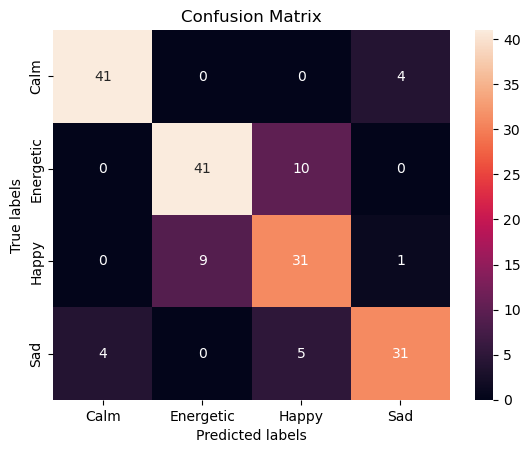

In [42]:
#get the confusion metric to see how many moods have been predicted wrong
from sklearn.metrics import confusion_matrix
#Create the confusion matrix using test data and predictions
confusion_matrix = confusion_matrix(y_test, best_ran_test_prediction)

#plot the confusion matrix
ax = plt.subplot()
sns.heatmap(confusion_matrix,annot=True,ax=ax)
labels = target_unique_encoded['mood'].tolist()
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)
plt.show()

In [43]:
from imblearn.over_sampling import ADASYN

# Apply ADASYN to balance the class distribution
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

In [44]:
clf.fit(X_train_resampled, y_train_resampled)

# Evaluate the model on the test set
y_train_pred_resampled = clf.predict(X_train_resampled)
y_test_pred_resampled = clf.predict(X_test)

train_res_f1 = f1_score(y_train_resampled, y_train_pred_resampled, average='macro')
test_res_f1 = f1_score(y_test, y_test_pred_resampled, average='macro')

print("Training F1 score: ", train_res_f1)
print("Testing F1 score: ", test_res_f1)
print("How far off is the model from the testing data to the training data: ", train_res_f1 - test_res_f1)


Training F1 score:  0.9987528379933444
Testing F1 score:  0.7898990332429512
How far off is the model from the testing data to the training data:  0.20885380475039317


In [45]:
print(classification_report(y_test, y_test_pred_resampled, digits=4))

              precision    recall  f1-score   support

           0     0.8723    0.9111    0.8913        45
           1     0.8125    0.7647    0.7879        51
           2     0.6458    0.7561    0.6966        41
           3     0.8529    0.7250    0.7838        40

    accuracy                         0.7910       177
   macro avg     0.7959    0.7892    0.7899       177
weighted avg     0.7982    0.7910    0.7921       177



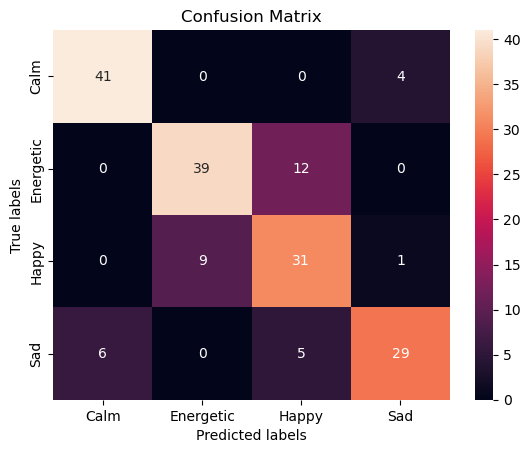

In [46]:
#get the confusion metric to see how many moods have been predicted wrong
from sklearn.metrics import confusion_matrix
#Create the confusion matrix using test data and predictions
confusion_matrix = confusion_matrix(y_test, y_test_pred_resampled)

#plot the confusion matrix
ax = plt.subplot()
sns.heatmap(confusion_matrix,annot=True,ax=ax)
labels = target_unique_encoded['mood'].tolist()
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)
plt.show()

## Final Model for deployment

In [47]:
#best clf from hyperparameter tuning above gotten with random serach cv
final_clf = RandomForestClassifier(max_depth=5, min_samples_split=5, n_jobs=-1)

In [48]:
#do exhaustive feature parameter search with best clf
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

efs_final = EFS(final_clf, min_features=1, max_features=10, scoring='f1_macro', cv=5, n_jobs=-1).fit(X_train, y_train)

Features: 1023/1023

In [49]:
# Get the best feature subset
best_features_final = list(efs.best_feature_names_)
print(best_features_final)
print(best_features)

['duration_ms', 'danceability', 'acousticness', 'energy', 'instrumentalness', 'valence', 'speechiness', 'tempo']
('duration_ms', 'danceability', 'acousticness', 'energy', 'instrumentalness', 'valence', 'speechiness', 'tempo')


In [50]:
print(efs.best_score_)
print(efs_final.best_score_)
print("Difference: ", efs.best_score_ - efs_final.best_score_)

0.8214115449390267
0.8165986385767334
Difference:  0.004812906362293257


In [51]:
# Reduce dataset to only the best features
X_train_reduced = X_train[best_features_final]
X_test_reduced = X_test[best_features_final]

In [52]:
# Train a new random forest classifier with the reduced feature set
clf_reduced_1 = RandomForestClassifier(max_depth=5, min_samples_split=5, n_jobs=-1)
clf_reduced_1.fit(X_train_reduced, y_train)

RandomForestClassifier(max_depth=5, min_samples_split=5, n_jobs=-1)

In [53]:
# Evaluate the model on the test set
y_train_pred_reduced = clf_reduced_1.predict(X_train_reduced)
y_test_pred_reduced = clf_reduced_1.predict(X_test_reduced)

red_f1_1_train = f1_score(y_train, y_train_pred_reduced, average='macro')
red_f1_1_test = f1_score(y_test, y_test_pred_reduced, average='macro')

print("Training F1 score: ", red_f1_1_train)
print("Testing F1 score: ", red_f1_1_test)
print("How far off is the model from the testing data to the training data: ", red_f1_1_train - red_f1_1_test)


Training F1 score:  0.8784180691411114
Testing F1 score:  0.8172298292952218
How far off is the model from the testing data to the training data:  0.061188239845889614


In [54]:
print(classification_report(y_test, y_test_pred_reduced, digits=4))

              precision    recall  f1-score   support

           0     0.9111    0.9111    0.9111        45
           1     0.8400    0.8235    0.8317        51
           2     0.6889    0.7561    0.7209        41
           3     0.8378    0.7750    0.8052        40

    accuracy                         0.8192       177
   macro avg     0.8195    0.8164    0.8172       177
weighted avg     0.8226    0.8192    0.8202       177



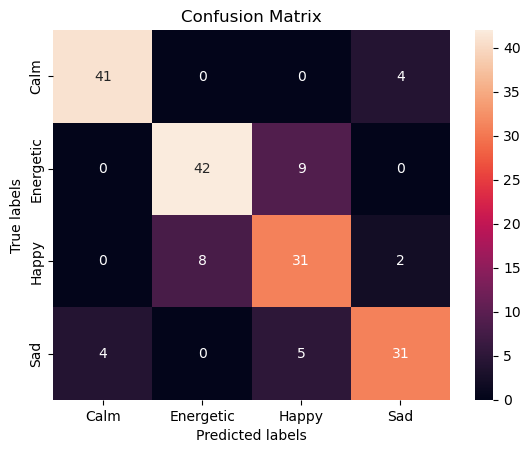

In [55]:
#get the confusion metric to see how many moods have been predicted wrong
from sklearn.metrics import confusion_matrix
#Create the confusion matrix using test data and predictions
confusion_matrix = confusion_matrix(y_test, y_test_pred_reduced)

#plot the confusion matrix
ax = plt.subplot()
sns.heatmap(confusion_matrix,annot=True,ax=ax)
labels = target_unique_encoded['mood'].tolist()
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)
plt.show()

In [56]:
# Train a new random forest classifier with the reduced feature set
clf_reduced_2 = RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_jobs=-1)
clf_reduced_2.fit(X_train_reduced, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_jobs=-1)

In [57]:
# Evaluate the model on the test set
y_train_pred_reduced_2 = clf_reduced_2.predict(X_train_reduced)
y_test_pred_reduced_2 = clf_reduced_2.predict(X_test_reduced)

red_f1_2_train = f1_score(y_train, y_train_pred_reduced_2, average='macro')
red_f1_2_test = f1_score(y_test, y_test_pred_reduced_2, average='macro')

print("Training F1 score: ", red_f1_2_train)
print("Testing F1 score: ", red_f1_2_test)
print("How far off is the model from the testing data to the training data: ", red_f1_2_train - red_f1_2_test)

Training F1 score:  0.9485133845416144
Testing F1 score:  0.824947468262075
How far off is the model from the testing data to the training data:  0.12356591627953939


In [58]:
print(classification_report(y_test, y_test_pred_reduced_2, digits=4))

              precision    recall  f1-score   support

           0     0.9318    0.9111    0.9213        45
           1     0.8367    0.8039    0.8200        51
           2     0.6809    0.7805    0.7273        41
           3     0.8649    0.8000    0.8312        40

    accuracy                         0.8249       177
   macro avg     0.8286    0.8239    0.8249       177
weighted avg     0.8312    0.8249    0.8268       177



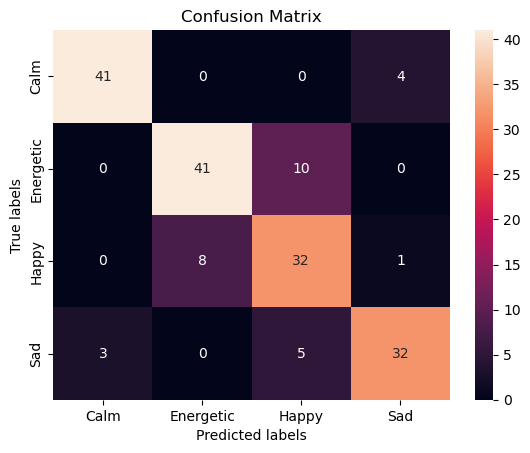

In [59]:
#get the confusion metric to see how many moods have been predicted wrong
from sklearn.metrics import confusion_matrix
#Create the confusion matrix using test data and predictions
confusion_matrix = confusion_matrix(y_test, y_test_pred_reduced_2)

#plot the confusion matrix
ax = plt.subplot()
sns.heatmap(confusion_matrix,annot=True,ax=ax)
labels = target_unique_encoded['mood'].tolist()
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)
plt.show()

### Taking the overal best model and modifiying the data with resampling to see if there is any improvement on the accuracy of the model

In [106]:
from imblearn.over_sampling import ADASYN

# Apply ADASYN to balance the class distribution using the reduced best features 
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_resampled_red, y_train_resampled_red = adasyn.fit_resample(X_train_reduced, y_train)

In [112]:
#the best overall model is the clf_reduced_2 because it performs better across all 4 classes 
clf_reduced_2.fit(X_train_resampled_red, y_train_resampled_red)
clf_reduced_2_res_train_pred = best_clf_grid.predict(X_train_resampled_red)
clf_reduced_2_res_test_pred = best_clf_grid.predict(X_test_reduced)

clf_reduced_2_res_train_f1 = f1_score(y_train_resampled_red, clf_reduced_2_res_train_pred, average='macro')
clf_reduced_2_res_test_f1 = f1_score(y_test, clf_reduced_2_res_test_pred, average='macro')

print("Training F1 score: ", grid_train_f1)
print("Testing F1 score: ", grid_test_f1)
print("How far off is the model from the testing data to the training data: ", clf_reduced_2_res_train_f1 - clf_reduced_2_res_test_f1)

Training F1 score:  0.9596924492822714
Testing F1 score:  0.8088078984041716
How far off is the model from the testing data to the training data:  0.1296441567782054


In [110]:
print(classification_report(y_test, clf_reduced_2_res_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9111    0.9111    0.9111        45
           1     0.8367    0.8039    0.8200        51
           2     0.6809    0.7805    0.7273        41
           3     0.8611    0.7750    0.8158        40

    accuracy                         0.8192       177
   macro avg     0.8225    0.8176    0.8185       177
weighted avg     0.8250    0.8192    0.8207       177



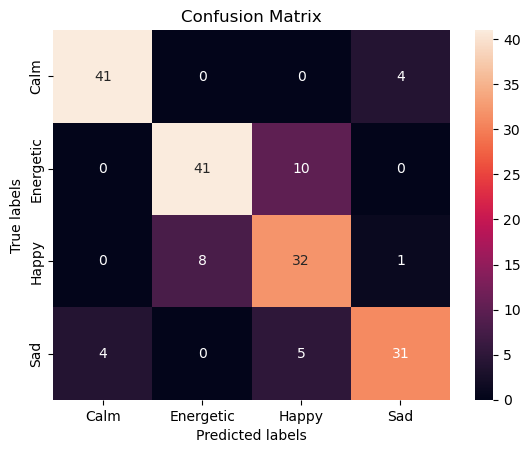

In [111]:
from sklearn.metrics import confusion_matrix
#Create the confusion matrix using test data and predictions
confusion_matrix = confusion_matrix(y_test, clf_reduced_2_res_test_pred)

#plot the confusion matrix
ax = plt.subplot()
sns.heatmap(confusion_matrix,annot=True,ax=ax)
labels = target_unique_encoded['mood'].tolist()
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)
plt.show()

In [113]:
#serialize(save) my trained model 
import joblib

joblib.dump(clf_reduced_2, 'mood_predictor_rf_model.pkl')

['mood_predictor_rf_model.pkl']